In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [2]:
df = pd.read_csv("online_retail_cleaned.csv")
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month,Day,Hour,DayOfWeek,DayName,MonthName
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,12,1,8,2,Wednesday,December
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,8,2,Wednesday,December
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,12,1,8,2,Wednesday,December
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,8,2,Wednesday,December
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,8,2,Wednesday,December


In [3]:
print("Kích thước dữ liệu:", df.shape)
print("Các cột dữ liệu:")
print(df.columns)


Kích thước dữ liệu: (392692, 16)
Các cột dữ liệu:
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Revenue', 'Year', 'Month', 'Day',
       'Hour', 'DayOfWeek', 'DayName', 'MonthName'],
      dtype='object')


In [4]:
analysis_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print("Ngày phân tích:", analysis_date)


Ngày phân tích: 2011-12-10 12:50:00


In [5]:
monetary_col = 'Revenue' if 'Revenue' in df.columns else 'TotalPrice'

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (analysis_date - x.max()).days,
    'InvoiceNo': 'nunique',
    monetary_col: 'sum'
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
rfm.head()


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [6]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.688081
std,1721.808492,100.014169,7.697998,8985.230220
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,306.482500
50%,15299.500000,51.000000,2.000000,668.570000
75%,16778.750000,142.000000,5.000000,1660.597500
max,18287.000000,374.000000,209.000000,280206.020000


In [7]:
rfm['Monetary'] = np.log1p(rfm['Monetary'])

In [8]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(
    rfm[['Recency', 'Frequency', 'Monetary']]
)

In [9]:
print("Silhouette score theo số cụm k:")
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    print(f"k = {k}, silhouette = {score:.4f}")


Silhouette score theo số cụm k:


D:\ai_practice_prj\env\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


k = 2, silhouette = 0.3717


D:\ai_practice_prj\env\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


k = 3, silhouette = 0.4227


...

k = 4, silhouette = 0.4169


D:\ai_practice_prj\env\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


k = 5, silhouette = 0.4085


D:\ai_practice_prj\env\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


k = 6, silhouette = 0.3652


In [10]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

D:\ai_practice_prj\env\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346,326,1,11.253955,0
1,12347,2,7,8.368925,0
2,12348,75,4,7.494564,0
3,12349,19,1,7.472245,0
4,12350,310,1,5.815324,2


In [11]:
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'CustomerID': 'count'
}).rename(columns={'CustomerID': 'Num_Customers'})

cluster_summary

,Recency,Frequency,Monetary,Num_Customers
Cluster,,,,
0,30.460205,8.597321,8.012240,1269
1,5.772727,77.454545,10.830323,22
2,253.517448,1.458624,5.649513,1003
3,53.015656,2.179550,6.119825,2044


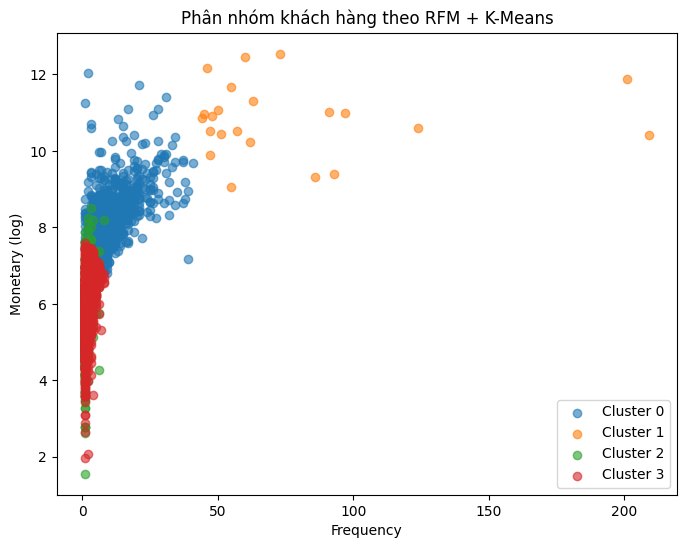

In [12]:
plt.figure(figsize=(8, 6))
for c in sorted(rfm['Cluster'].unique()):
    temp = rfm[rfm['Cluster'] == c]
    plt.scatter(
        temp['Frequency'],
        temp['Monetary'],
        label=f'Cluster {c}',
        alpha=0.6
    )
plt.xlabel("Frequency")
plt.ylabel("Monetary (log)")
plt.title("Phân nhóm khách hàng theo RFM + K-Means")
plt.legend()
plt.show()

In [15]:
cluster_summary = rfm.groupby('Cluster').agg(
    Num_Customers=('CustomerID', 'count'),
    Total_Revenue=('Monetary', 'sum'),
    Avg_Revenue=('Monetary', 'mean')
).reset_index()
cluster_summary['Customer_Ratio (%)'] = (
    cluster_summary['Num_Customers'] / cluster_summary['Num_Customers'].sum() * 100
)
cluster_summary['Revenue_Ratio (%)'] = (
    cluster_summary['Total_Revenue'] / cluster_summary['Total_Revenue'].sum() * 100
)
cluster_summary['Customer_Ratio (%)'] = cluster_summary['Customer_Ratio (%)'].round(2)
cluster_summary['Revenue_Ratio (%)'] = cluster_summary['Revenue_Ratio (%)'].round(2)
print(cluster_summary)

   Cluster  Num_Customers  Total_Revenue  Avg_Revenue  Customer_Ratio (%)  \
0        0           1269   10167.532176     8.012240               29.25   
1        1             22     238.267112    10.830323                0.51   
2        2           1003    5666.461159     5.649513               23.12   
3        3           2044   12508.922707     6.119825               47.12   

   Revenue_Ratio (%)  
0              35.57  
1               0.83  
2              19.83  
3              43.77  


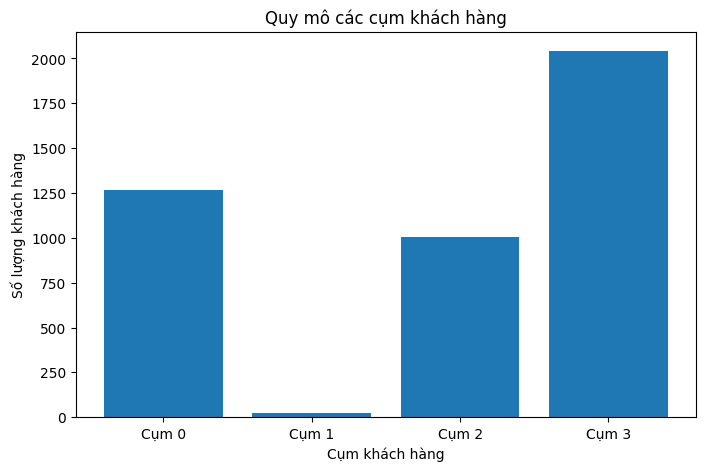

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(
    [f'Cụm {c}' for c in cluster_summary['Cluster']],
    cluster_summary['Num_Customers']
)
plt.xlabel("Cụm khách hàng")
plt.ylabel("Số lượng khách hàng")
plt.title("Quy mô các cụm khách hàng")
plt.show()

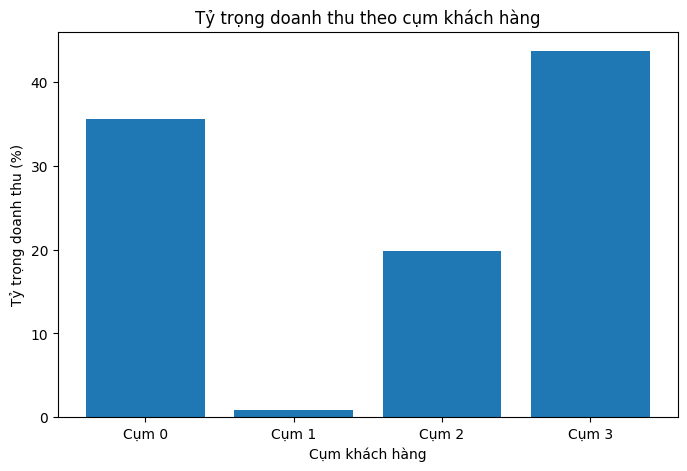

In [19]:
plt.figure(figsize=(8, 5))
plt.bar(
    [f'Cụm {c}' for c in cluster_summary['Cluster']],
    cluster_summary['Revenue_Ratio (%)']
)
plt.xlabel("Cụm khách hàng")
plt.ylabel("Tỷ trọng doanh thu (%)")
plt.title("Tỷ trọng doanh thu theo cụm khách hàng")
plt.show()

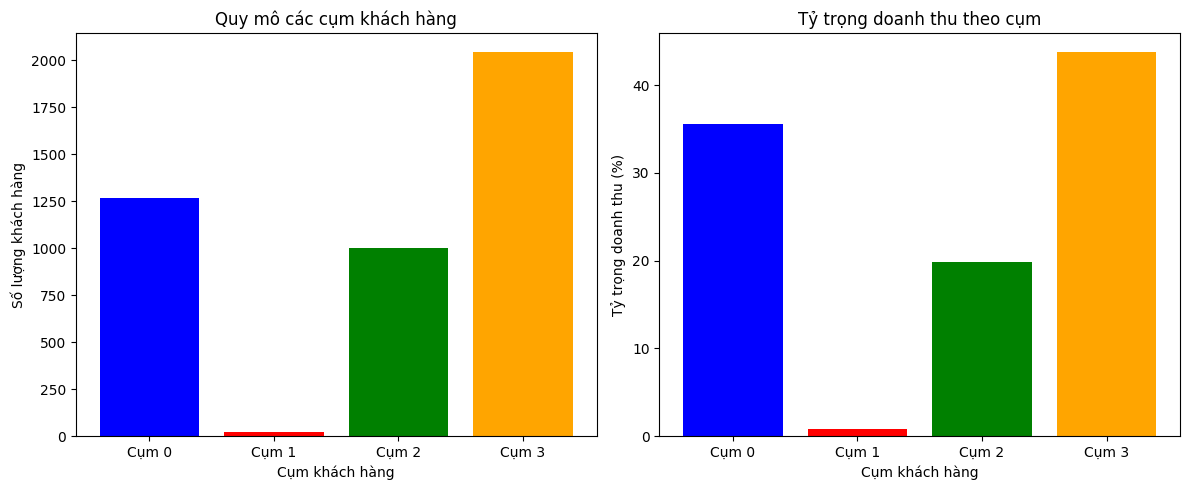

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Biểu đồ 1: Quy mô khách hàng
ax1.bar([f'Cụm {c}' for c in cluster_summary['Cluster']], 
        cluster_summary['Num_Customers'],
        color=['blue', 'red', 'green', 'orange'])
ax1.set_xlabel("Cụm khách hàng")
ax1.set_ylabel("Số lượng khách hàng")
ax1.set_title("Quy mô các cụm khách hàng")

# Biểu đồ 2: Tỷ trọng doanh thu
ax2.bar([f'Cụm {c}' for c in cluster_summary['Cluster']], 
        cluster_summary['Revenue_Ratio (%)'],
        color=['blue', 'red', 'green', 'orange'])
ax2.set_xlabel("Cụm khách hàng")
ax2.set_ylabel("Tỷ trọng doanh thu (%)")
ax2.set_title("Tỷ trọng doanh thu theo cụm")

plt.tight_layout()
plt.show()